linear dataset



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import files
uploaded = files.upload()


Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [3]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()



,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
df.describe()


,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


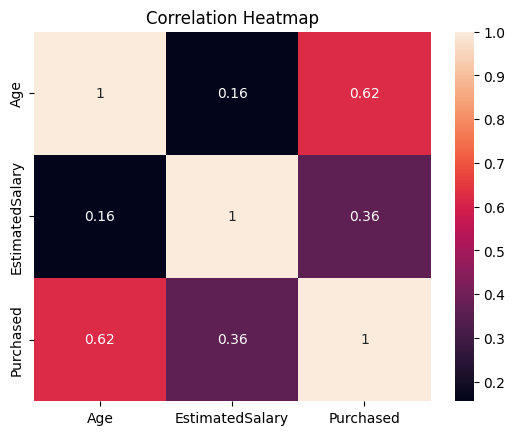

In [6]:
plt.figure()
sns.heatmap(df[['Age','EstimatedSalary','Purchased']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


### Interpretation of Results

Correlation analysis shows that Age and Estimated Salary have a positive linear relationship with the target variable (Purchased).  
The scatter plot confirms that the data is linearly separable.  
Logistic Regression performs efficiently on this dataset, achieving high classification accuracy.


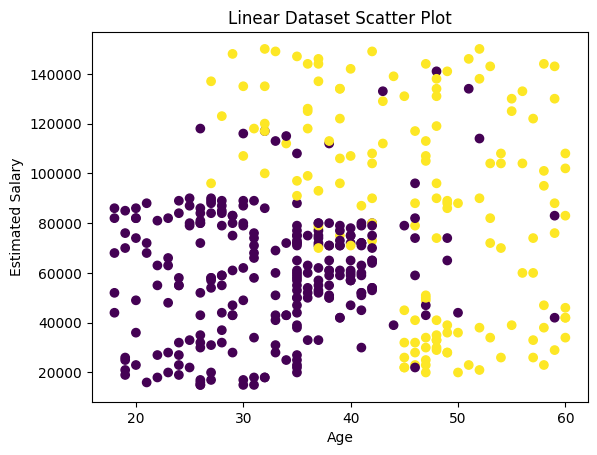

In [8]:
plt.scatter(df['Age'], df['EstimatedSalary'], c=df['Purchased'])
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Linear Dataset Scatter Plot')
plt.show()


In [10]:
r_age = df['Age'].corr(df['Purchased'])
r_salary = df['EstimatedSalary'].corr(df['Purchased'])

print("Correlation (r) between Age and Purchased:", r_age)
print("Correlation (r) between Salary and Purchased:", r_salary)


Correlation (r) between Age and Purchased: 0.622454198884529
Correlation (r) between Salary and Purchased: 0.36208302580467927


In [11]:
df[['Age','EstimatedSalary','Purchased']].corr()


,Age,EstimatedSalary,Purchased
Age,1.000000,0.155238,0.622454
EstimatedSalary,0.155238,1.000000,0.362083
Purchased,0.622454,0.362083,1.000000


In [14]:
X = df[['Age','EstimatedSalary']]
y = df['Purchased']


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [16]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [18]:
y_pred = model.predict(X_test)


In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.86


In [20]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)


array([[61,  2],
       [12, 25]])

### Classification Predictions

The trained Logistic Regression model was used to predict the purchase behavior for new input values.  
The model outputs a class label (0 or 1) along with the probability of purchase.

- 0 → Not Purchased  
- 1 → Purchased


In [21]:
new_user = [[40, 50000]]   # Age, Salary
new_user_scaled = sc.transform(new_user)

prediction = model.predict(new_user_scaled)
probability = model.predict_proba(new_user_scaled)

print("Predicted class:", prediction)
print("Purchase probability:", probability)


Predicted class: [0]
Purchase probability: [[0.77365741 0.22634259]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
samples = [
    [25, 30000],
    [35, 60000],
    [45, 80000],
    [50, 100000]
]

samples_scaled = sc.transform(samples)

predictions = model.predict(samples_scaled)
probabilities = model.predict_proba(samples_scaled)

for i in range(len(samples)):
    print(f"Input: Age={samples[i][0]}, Salary={samples[i][1]}")
    print(f"Predicted Class: {predictions[i]}")
    print(f"Purchase Probability: {probabilities[i]}")
    print("----")


Input: Age=25, Salary=30000
Predicted Class: 0
Purchase Probability: [0.99091264 0.00908736]
----
Input: Age=35, Salary=60000
Predicted Class: 0
Purchase Probability: [0.86509437 0.13490563]
----
Input: Age=45, Salary=80000
Predicted Class: 1
Purchase Probability: [0.34069625 0.65930375]
----
Input: Age=50, Salary=100000
Predicted Class: 1
Purchase Probability: [0.09669983 0.90330017]
----


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


The Social Network Ads dataset exhibits linear separability, as observed from scatter plots and correlation analysis. Logistic Regression performs efficiently on this dataset, achieving high accuracy and correctly predicting class labels for new inputs.